In [1]:
import yfinance as yf
import pandas as pd
import numpy as np

In [34]:
import matplotlib.pyplot as plt
from tqdm import tqdm

In [35]:
def proportion_for_optimal_median(asset1, asset2):
    max_med = 0
    max_proportion = 0
    for stock_proportion in tqdm(np.linspace(0.0, 1.0, 101)):
        strategy_simulated_ret = stock_proportion * asset1 + (1 - stock_proportion) * asset2
        med = np.median(strategy_simulated_ret)

        if med > max_med:
            max_med = med
            max_proportion = stock_proportion
            
    return {'prop1': max_proportion, 'prop2': 1 - max_proportion}

In [5]:
asset1 = yf.Ticker('LANNA.BK')
asset2 = yf.Ticker('HFT.BK')

In [6]:
interval = '1d'
start = '2020-1-1'
end = '2025-1-1'

In [7]:
asset1_df = asset1.history(interval='1d',start=start,end=end)
asset2_df = asset2.history(interval='1d',start=start,end=end)

In [8]:
asset1_df.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2020-01-02 00:00:00+07:00,4.052894,4.105529,3.947624,4.105529,308000,0.0,0.0
2020-01-03 00:00:00+07:00,4.105529,4.131847,4.079212,4.105529,1543800,0.0,0.0
2020-01-06 00:00:00+07:00,4.079212,4.105529,4.052894,4.052894,126100,0.0,0.0
2020-01-07 00:00:00+07:00,4.105529,4.105529,4.026577,4.079212,181900,0.0,0.0
2020-01-08 00:00:00+07:00,4.079211,4.079211,3.973942,4.000259,83400,0.0,0.0


In [10]:
asset2_df.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2020-01-02 00:00:00+07:00,2.046873,2.060339,2.033407,2.033407,160100,0.0,0.0
2020-01-03 00:00:00+07:00,2.033407,2.046873,2.019940,2.033407,639200,0.0,0.0
2020-01-06 00:00:00+07:00,2.019940,2.019940,2.006474,2.006474,592300,0.0,0.0
2020-01-07 00:00:00+07:00,2.046873,2.046873,2.019940,2.019940,40900,0.0,0.0
2020-01-08 00:00:00+07:00,2.019940,2.019940,1.993008,2.019940,744100,0.0,0.0


In [13]:
prices = pd.DataFrame({'ast1': asset1_df['Close'], 'ast2': asset2_df['Close']})
returns = np.log(prices).diff(periods=1).dropna()

In [14]:
ast1_ret = returns['ast1'].values
ast2_ret = returns['ast2'].values

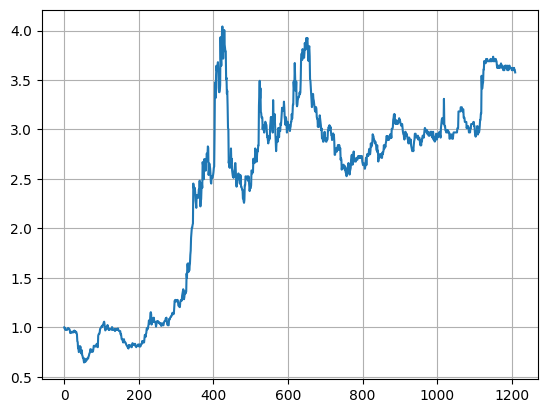

In [29]:
ast1_portfolio = ast1_ret
plt.grid(True)
plt.plot(np.exp(np.cumsum(ast1_portfolio)));

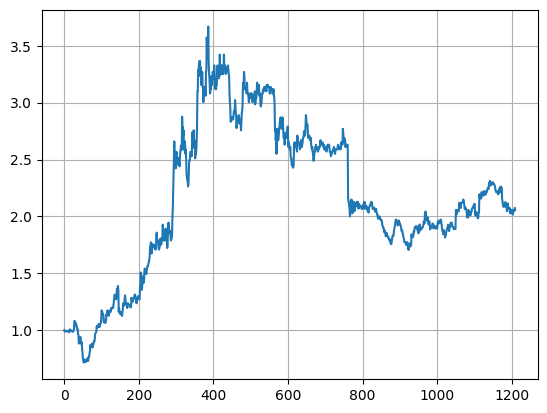

In [31]:
ast2_portfolio = ast2_ret 
plt.grid(True)
plt.plot(np.exp(np.cumsum(ast2_portfolio)));

In [22]:
def bootstrapping(rets, num_paths=100000, num_time=252):
    bootstraped_paths = np.random.choice(np.arange(rets.shape[0]), size=(num_paths, num_time), replace=True)

    bootstrap_sample = rets[bootstraped_paths]
    return bootstrap_sample

In [32]:
for year in [2020, 2021, 2022, 2023, 2024]:
    
    ast1_ret = returns[returns.index.year == year]['ast1'].values
    ast2_ret = returns[returns.index.year == year]['ast2'].values
    
    boot_ast1 = bootstrapping(ast1_ret, 10000)
    boot_ast2 = bootstrapping(ast2_ret, 10000)

    rets_1 =  np.exp(np.cumsum(boot_ast1, axis=1))
    rets_2 =  np.exp(np.cumsum(boot_ast2, axis=1))

    print(f'year: {year} | median asset1: {np.median(rets_1)} | median asset2: {np.median(rets_2)} ')

year: 2020 | median asset1: 1.0239476845025206 | median asset2: 1.2715635934926592 
year: 2021 | median asset1: 1.3708967017830536 | median asset2: 1.311131853761142 
year: 2022 | median asset1: 1.1062696522378965 | median asset2: 0.9117608831138511 
year: 2023 | median asset1: 1.0079930928308767 | median asset2: 0.8935234685161633 
year: 2024 | median asset1: 1.0669561992158323 | median asset2: 1.0188096986991628 


In [39]:
ast1_ret = returns['ast1'].values
ast2_ret = returns['ast2'].values

boot_ast1 = bootstrapping(ast1_ret, 100000)
boot_ast2 = bootstrapping(ast2_ret, 100000)

rets_1 =  np.exp(np.cumsum(boot_ast1, axis=1))
rets_2 =  np.exp(np.cumsum(boot_ast2, axis=1))

In [40]:
res = proportion_for_optimal_median(rets_1, rets_2)

100%|██████████| 101/101 [00:12<00:00,  7.94it/s]


In [41]:
res

{'prop1': np.float64(1.0), 'prop2': np.float64(0.0)}